In [1]:
import time
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from IPython.display import clear_output, display

### Timelike Geodesics in Schwarzschild Spacetime

Effective potential:

$\qquad\displaystyle V_{\mathrm{eff}}(r)=\left(1-\frac{2M}{r}\right)\left(1+\frac{L^2}{r^2}\right)$

Energy equation for timelike geodesics:

$\qquad\displaystyle\left(\frac{dr}{d\tau}\right)^2+V_{\mathrm{eff}}(r)=E^2$

Radial motion:

$\qquad\displaystyle\frac{dr}{d\tau}=-\sqrt{E^2-V_{\mathrm{eff}}(r)}$

Angular motion:

$\qquad\displaystyle\frac{d\phi}{d\tau}=\frac{L}{r^2}$

Cartesian coordinates:

$\qquad\displaystyle x=r\cos\phi \qquad\, y=r\sin\phi$

Schwarzschild metric:

$\qquad\displaystyle ds^2=-\left(1-\frac{2M}{r}\right)dt^2+\left(1-\frac{2M}{r}\right)^{-1}dr^2+r^2(d\theta^2+\sin^2\theta\,d\phi^2)$


 
Energy per unit mass:

$\qquad\displaystyle E=\left(1-\frac{2M}{r}\right)\frac{dt}{d\tau}$

Angular momentum per unit mass:

$\qquad\displaystyle L=r^2\frac{d\phi}{d\tau}$

Stable/unstable circular orbits satisfy:

$\qquad\displaystyle \frac{dV_{\mathrm{eff}}}{dr}=0$

Stability condition:

$\qquad\displaystyle \frac{d^2V_{\mathrm{eff}}}{dr^2}>0$

***Innermost Stable Circular Orbit (ISCO)***

For Schwarzschild black holes:

$\qquad\displaystyle r_{\mathrm{ISCO}}=6M$

Unstable photon orbit radius:

$\qquad\displaystyle r_{\mathrm{ph}}=3M$

Schwarzschild radius:

$\qquad\displaystyle r_s=2M$

General relativistic equation of motion:

$\qquad\displaystyle \frac{d^2x^\mu}{d\tau^2}+\Gamma^\mu_{\alpha\beta}\frac{dx^\alpha}{d\tau}\frac{dx^\beta}{d\tau}=0$

**Orbit Classification**

Depending on $(E)$ and $(L)$:

* bound orbits,
* plunging orbits,
* scattering orbits,
* zoom–whirl trajectories

can occur.

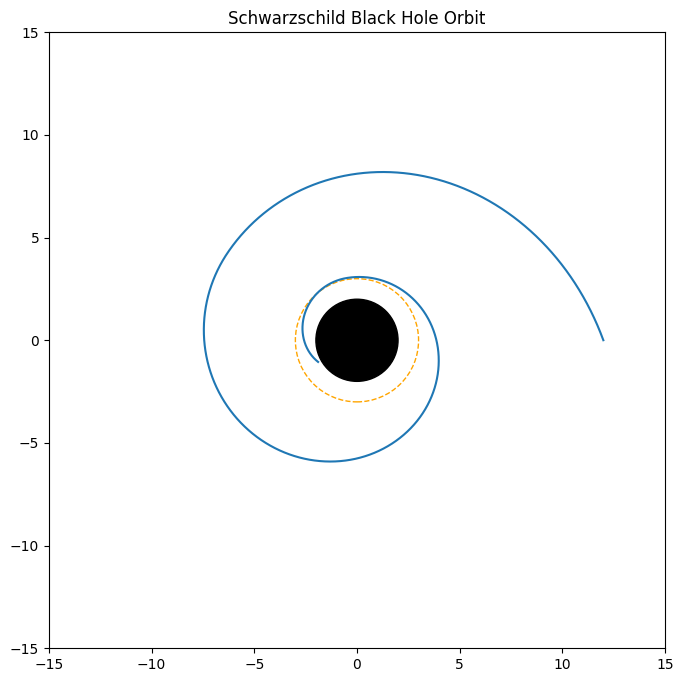

In [5]:
M = 1.0              # Geometric units: G = c = M = 1
L = 4.0              # Angular momentum
E = 0.97             # Energy
dt = 0.01            # Time step
steps = 12000        # Number of steps
r = 12.0
phi = 0.0
xs,ys = [],[]

fig, ax = plt.subplots(figsize=(8,8))
for n in range(steps):
    Veff = (1 - 2*M/r)*(1 + L**2/r**2)  # Effective potential
    dr = -np.sqrt(abs(E**2 - Veff))     # Radial velocity
    dphi = L / r**2                     # Angular equation
    r += dr * dt
    phi += dphi * dt
    x, y = r*np.cos(phi),r*np.sin(phi)
    xs.append(x)
    ys.append(y)

    if r <= 2.05:
        break

    if n % 20 == 0:
        clear_output(wait=True)
        ax.clear()
        ax.plot(xs, ys, lw=1.5)
        black_hole = plt.Circle((0,0), 2, color='black')
        ax.add_patch(black_hole)
        photon = plt.Circle((0,0), 3, color='orange', fill=False, linestyle='--' )
        ax.add_patch(photon)
        ax.set_xlim(-15,15)
        ax.set_ylim(-15,15)
        ax.set_aspect('equal')
        ax.set_title("Schwarzschild Black Hole Orbit")
        display(fig)
        time.sleep(0.001)
plt.close()

### Schwarzschild Gravitational Lensing via Photon Ray Dynamics


Photon radial distance:

$\qquad\displaystyle r=\sqrt{x^2+y^2}$

Effective gravitational acceleration used in the simulation:

$\qquad\displaystyle a_x=-\frac{4Mx}{r^4}$

$\qquad\displaystyle a_y=-\frac{4My}{r^4}$

Velocity update:

$\qquad\displaystyle v_x\rightarrow v_x+a_x\,dt$

$\qquad\displaystyle v_y\rightarrow v_y+a_y\,dt$

Speed normalization:

$\qquad\displaystyle v=\sqrt{v_x^2+v_y^2}$

$\qquad\displaystyle v_x\rightarrow\frac{v_x}{v}$

$\qquad\displaystyle v_y\rightarrow\frac{v_y}{v}$

Position update:

$\qquad\displaystyle x\rightarrow x+v_x\,dt$

$\qquad\displaystyle y\rightarrow y+v_y\,dt$

Schwarzschild photon sphere radius:

$\qquad\displaystyle r_{\mathrm{ph}}=3M$

Weak-field GR light deflection:

$\qquad\displaystyle \alpha\approx\frac{4M}{b}$


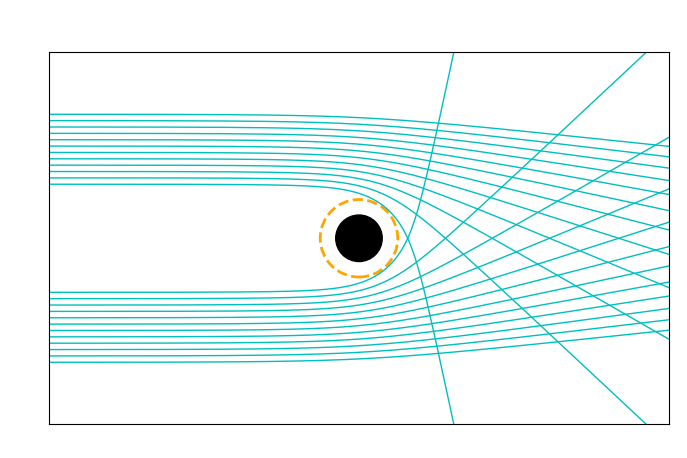

In [3]:
fig, ax = plt.subplots(figsize=(8,8))
M = 1
rays = []
dt = 0.05
steps = 1200

for y0 in np.linspace(-8, 8, 40):
    x, y = -20, y0
    vx, vy = 1.0, 0.0
    xs, ys = [], []
    rays.append({"x": x, "y": y, "vx": vx, "vy": vy, "xs": xs, "ys": ys, "alive": True})

for step in range(steps):
    clear_output(wait=True)
    ax.clear()
    black_hole = plt.Circle((0,0), 1.5, color='black')
    ax.add_patch(black_hole)
    photon_sphere = plt.Circle((0,0),2.5,color='orange',fill=False,linestyle='--',lw=2)
    ax.add_patch(photon_sphere)
    for ray in rays:
        if not ray["alive"]:
            continue

        x, y = ray["x"], ray["y"]
        vx, vy = ray["vx"], ray["vy"]
        r = np.sqrt(x**2 + y**2)
        if r < 1.6:                     # absorbed by black hole
            ray["alive"] = False
            continue

        axx, ayy = -4*M*x/(r**4), -4*M*y/(r**4)
        vx += axx*dt
        vy += ayy*dt
        speed = np.sqrt(vx**2 + vy**2)  # normalize speed
        vx /= speed
        vy /= speed
        x += vx*dt
        y += vy*dt
        ray["x"],ray["y"] = x, y
        ray["vx"], ray["vy"] = vx, vy
        ray["xs"].append(x)
        ray["ys"].append(y)
        ax.plot(ray["xs"],ray["ys"],color='c',lw=1)
    ax.set_xlim(-20,20)
    ax.set_ylim(-12,12)
    ax.set_aspect('equal')
    ax.set_title(f"Animated Gravitational Lensing\nStep = {step}",color='white')
    ax.tick_params(colors='white')
    display(fig)
    time.sleep(0.0001)
plt.close()

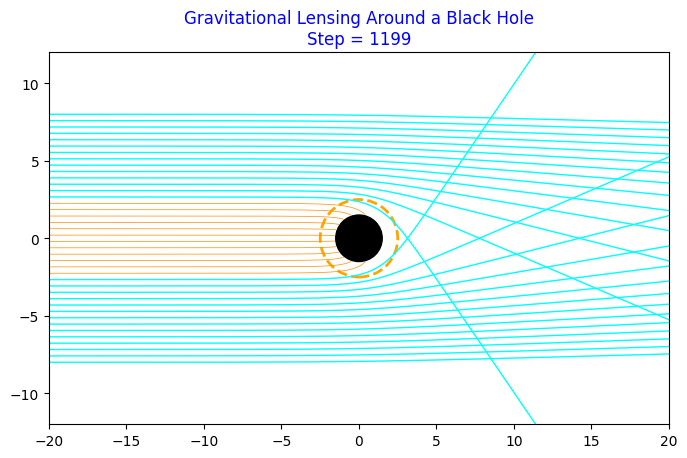

In [4]:
M = 1
rays = []
dt = 0.05
steps = 1200

for y0 in np.linspace(-8, 8, 40):
    x,y = -20,y0
    vx,vy = 1.0, 0.0
    xs,ys = [],[]
    rays.append({"x": x, "y": y, "vx": vx, "vy": vy, "xs": xs, "ys": ys, "alive": True, "captured": False })

fig, ax = plt.subplots(figsize=(8,8))
for step in range(steps):
    clear_output(wait=True)
    ax.clear()
    black_hole = plt.Circle((0,0), 1.5, color='black')
    ax.add_patch(black_hole)
    photon_sphere = plt.Circle((0,0), 2.5, color='orange', fill=False, linestyle='--', lw=2)
    ax.add_patch(photon_sphere)
    for ray in rays:
        if ray["captured"]:
            ax.plot(ray["xs"], ray["ys"], color='darkorange', lw=0.5)
            continue
        if not ray["alive"]:
            continue

        x,y = ray["x"],ray["y"]
        vx, vy = ray["vx"],ray["vy"]
        r = np.sqrt(x**2 + y**2)
        if r < 1.6:
            ray["xs"].append(x)
            ray["ys"].append(y)
            ray["alive"] = False
            ray["captured"] = True
            continue
 
        factor = 1 + 8/(r**2)
        axx, ayy = -factor*M*x/(r**4),  -factor*M*y/(r**4)
        vx += axx*dt
        vy += ayy*dt
        speed = np.sqrt(vx**2 + vy**2)
        vx /= speed
        vy /= speed
        x += vx*dt
        y += vy*dt
        ray["x"], ray["y"] = x, y
        ray["vx"], ray["vy"] = vx, vy
        ray["xs"].append(x)
        ray["ys"].append(y)
        ax.plot(ray["xs"], ray["ys"], color='cyan', lw=1)
    ax.set_xlim(-20,20)
    ax.set_ylim(-12,12)
    ax.set_aspect('equal')
    ax.set_title(f"Gravitational Lensing Around a Black Hole\nStep = {step}",color='blue')
    display(fig)
    time.sleep(0.001)
plt.close()

### Photon Dynamics Around Two Schwarzschild Black Holes

Distance from each black hole:

$\qquad\displaystyle r_1=\sqrt{(x-x_1)^2+(y-y_1)^2}$

$\qquad\displaystyle r_2=\sqrt{(x-x_2)^2+(y-y_2)^2}$

Combined gravitational acceleration:

$\qquad\displaystyle a_x=-\frac{4M_1(x-x_1)}{r_1^4}-\frac{4M_2(x-x_2)}{r_2^4}$

$\qquad\displaystyle a_y=-\frac{4M_1(y-y_1)}{r_1^4}-\frac{4M_2(y-y_2)}{r_2^4}$

Velocity evolution:

$\qquad\displaystyle v_x\rightarrow v_x+a_x\,dt$

$\qquad\displaystyle v_y\rightarrow v_y+a_y\,dt$

Speed normalization:

$\qquad\displaystyle v=\sqrt{v_x^2+v_y^2}$

$\qquad\displaystyle v_x\rightarrow\frac{v_x}{v}$

$\qquad\displaystyle v_y\rightarrow\frac{v_y}{v}$

Position evolution:

$\qquad\displaystyle x\rightarrow x+v_x\,dt$

$\qquad\displaystyle y\rightarrow y+v_y\,dt$

Weak-field gravitational lensing approximation:

$\qquad\displaystyle  \alpha\approx\frac{4M}{b}$


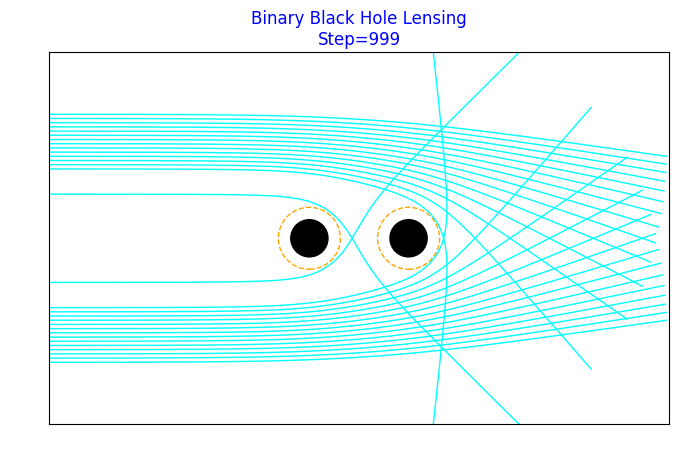

In [5]:
bh1 = np.array([-4.0, 0.0])
bh2 = np.array([ 4.0, 0.0])
M1 = 1.0
M2 = 1.0
dt = 0.05
rays = []
for y0 in np.linspace(-10,10,60):
    rays.append({"x": -25.0, "y": y0, "vx": 1.0, "vy": 0.0, "xs": [], "ys": [],"alive": True})

fig, ax = plt.subplots(figsize=(8,8))
for step in range(1000):
    clear_output(wait=True)
    ax.clear()
    ax.add_patch(plt.Circle(bh1,1.5,color='black'))
    ax.add_patch(plt.Circle(bh2,1.5,color='black'))
    ax.add_patch(plt.Circle( bh1, 2.5, color='orange', fill=False, linestyle='--'))
    ax.add_patch(plt.Circle(bh2, 2.5, color='orange', fill=False, linestyle='--'))

    for ray in rays:
        if not ray["alive"]:
            continue

        x,y = ray["x"], ray["y"]
        vx,vy = ray["vx"], ray["vy"]
        r1 = np.sqrt((x-bh1[0])**2 + (y-bh1[1])**2)
        r2 = np.sqrt((x-bh2[0])**2 + (y-bh2[1])**2)
        if r1 < 1.6 or r2 < 1.6:
            ray["alive"] = False
            continue

        axx = (-4*M1*(x-bh1[0])/(r1**4) -4*M2*(x-bh2[0])/(r2**4))
        ayy = (-4*M1*(y-bh1[1])/(r1**4)-4*M2*(y-bh2[1])/(r2**4))
        vx += axx*dt
        vy += ayy*dt
        speed = np.sqrt(vx**2 + vy**2)
        vx /= speed
        vy /= speed
        x += vx*dt
        y += vy*dt
        ray["x"],ray["y"] = x,y
        ray["vx"],ray["vy"] = vx,vy
        ray["xs"].append(x)
        ray["ys"].append(y)
        ax.plot(ray["xs"],ray["ys"],color='cyan',lw=1)
    ax.set_xlim(-25,25)
    ax.set_ylim(-15,15)
    ax.set_aspect('equal')
    ax.set_title(f"Binary Black Hole Lensing\nStep={step}", color='blue')
    ax.tick_params(colors='white')
    display(fig)
    time.sleep(0.001)
plt.close()

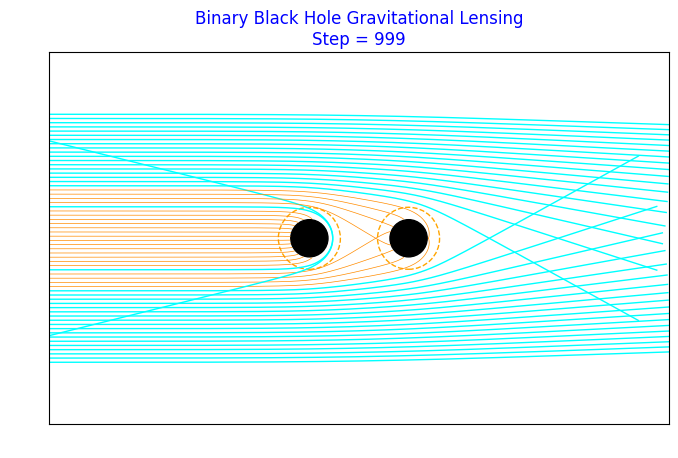

In [6]:
bh1 = np.array([-4.0, 0.0])
bh2 = np.array([ 4.0, 0.0])
M1 = 1.0
M2 = 1.0
dt = 0.05
steps = 1000
rays = []
for y0 in np.linspace(-10,10,60):
    rays.append({"x": -25.0, "y": y0, "vx": 1.0, "vy": 0.0, "xs": [], "ys": [],"alive": True,"captured": False})

fig, ax = plt.subplots(figsize=(8,8))
for step in range(steps):
    clear_output(wait=True)
    ax.clear()
    ax.add_patch(plt.Circle(bh1, 1.5, color='black'))
    ax.add_patch(plt.Circle(bh2, 1.5, color='black'))
    ax.add_patch(plt.Circle( bh1, 2.5, color='orange', fill=False, linestyle='--'))
    ax.add_patch(plt.Circle(bh2, 2.5, color='orange', fill=False, linestyle='--'))
    for ray in rays:
        if ray["captured"]:
            ax.plot(ray["xs"], ray["ys"], color='darkorange', lw=0.5)
            continue

        if not ray["alive"]:
            continue

        x, y = ray["x"], ray["y"]
        vx, vy = ray["vx"], ray["vy"]
        r1 = np.sqrt((x-bh1[0])**2 + (y-bh1[1])**2)
        r2 = np.sqrt((x-bh2[0])**2 + (y-bh2[1])**2)
        if r1 < 1.6 or r2 < 1.6:
            ray["xs"].append(x)
            ray["ys"].append(y)
            ray["alive"] = False
            ray["captured"] = True
            continue

        factor1 = 1 + 8/(r1**2)
        factor2 = 1 + 8/(r2**2)
        axx = (-factor1*M1*(x-bh1[0])/(r1**4)-factor2*M2*(x-bh2[0])/(r2**4))
        ayy = (-factor1*M1*(y-bh1[1])/(r1**4)-factor2*M2*(y-bh2[1])/(r2**4))
        vx += axx*dt
        vy += ayy*dt
        speed = np.sqrt(vx**2 + vy**2)
        vx /= speed
        vy /= speed
        x += vx*dt
        y += vy*dt
        ray["x"], ray["y"] = x, y
        ray["vx"], ray["vy"] = vx, vy
        ray["xs"].append(x)
        ray["ys"].append(y)
        ax.plot(ray["xs"], ray["ys"], color='cyan', lw=1)
    ax.set_xlim(-25,25)
    ax.set_ylim(-15,15)
    ax.set_aspect('equal')
    ax.set_title(f"Binary Black Hole Gravitational Lensing\nStep = {step}",color='blue')
    ax.tick_params(colors='white')
    display(fig)
    time.sleep(0.001)
plt.close()

### Photon Ray Dynamics in Kerr Spacetime

Radial distance:

$\qquad\displaystyle r=\sqrt{x^2+y^2}$

Schwarzschild-like gravitational acceleration:

$\qquad\displaystyle a_x=-\frac{4Mx}{r^4}$

$\qquad\displaystyle a_y=-\frac{4My}{r^4}$

Frame-dragging terms (rotation-induced deflection):

$\qquad\displaystyle a_x\rightarrow a_x-\frac{a v_y}{r^2}$

$\qquad\displaystyle a_y\rightarrow a_y+\frac{a v_x}{r^2}$

Velocity evolution:

$\qquad\displaystyle v_x\rightarrow v_x+a_x\,dt$

$\qquad\displaystyle v_y\rightarrow v_y+a_y\,dt$

Speed normalization:

$\qquad\displaystyle v=\sqrt{v_x^2+v_y^2}$

$\qquad\displaystyle v_x\rightarrow\frac{v_x}{v}$

$\qquad\displaystyle v_y\rightarrow\frac{v_y}{v}$

Position evolution:

$\qquad\displaystyle x\rightarrow x+v_x\,dt$

$\qquad\displaystyle y\rightarrow y+v_y\,dt$

Kerr metric:

$\qquad\displaystyle ds^2=-\left(1-\frac{2Mr}{\Sigma}\right)dt^2-\frac{4Mar\sin^2\theta}{\Sigma}dt\,d\phi+\frac\Sigma\Delta dr^2+\Sigma d\theta^2+\left(r^2+a^2+\frac{2Ma^2r\sin^2\theta}{\Sigma}\right)\sin^2\theta\,d\phi^2$

with

$\qquad\displaystyle \Sigma=r^2+a^2\cos^2\theta$

and

$\qquad\displaystyle \Delta=r^2-2Mr+a^2$


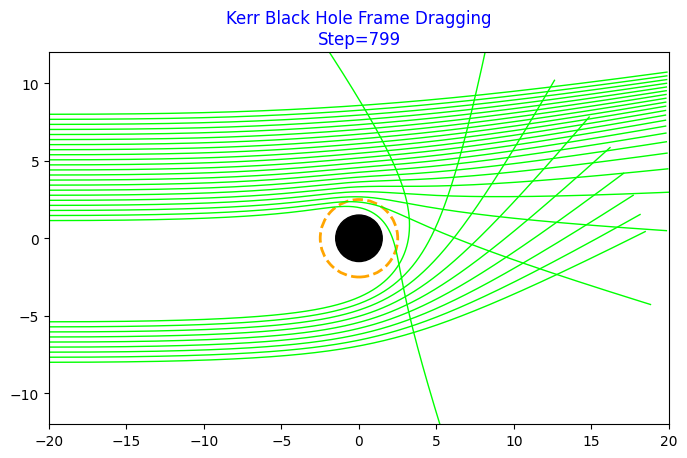

In [7]:
dt = 0.05
M = 1
a = 0.8   # spin parameter
rays = []
for y0 in np.linspace(-8,8,50):
    rays.append({"x": -20, "y": y0, "vx": 1.0,"vy": 0.0,"xs": [],"ys": [],"alive": True})

fig, ax = plt.subplots(figsize=(8,8))
for step in range(800):
    clear_output(wait=True)
    ax.clear()
    ax.add_patch(plt.Circle((0,0),1.5,color='black'))
    ax.add_patch(plt.Circle((0,0), 2.5, color='orange', fill=False, linestyle='--', lw=2))
    for ray in rays:
        if not ray["alive"]:
            continue

        x,y = ray["x"],ray["y"]
        vx,vy = ray["vx"],ray["vy"]
        r = np.sqrt(x**2+y**2)

        if r < 1.6:
            ray["alive"] = False
            continue

        axx = -4*M*x/(r**4)
        ayy = -4*M*y/(r**4)
        axx += -a*vy/(r**2)
        ayy +=  a*vx/(r**2)
        vx += axx*dt
        vy += ayy*dt
        speed = np.sqrt(vx**2+vy**2)
        vx /= speed
        vy /= speed
        x += vx*dt
        y += vy*dt
        ray["x"],ray["y"] = x,y
        ray["vx"],ray["vy"] = vx,vy
        ray["xs"].append(x)
        ray["ys"].append(y)
        ax.plot(ray["xs"],ray["ys"],color='lime',lw=1)
    ax.set_xlim(-20,20)
    ax.set_ylim(-12,12)
    ax.set_aspect('equal')
    ax.set_title(f"Kerr Black Hole Frame Dragging\nStep={step}",color='blue')
    display(fig)
    time.sleep(0.001)
plt.close()

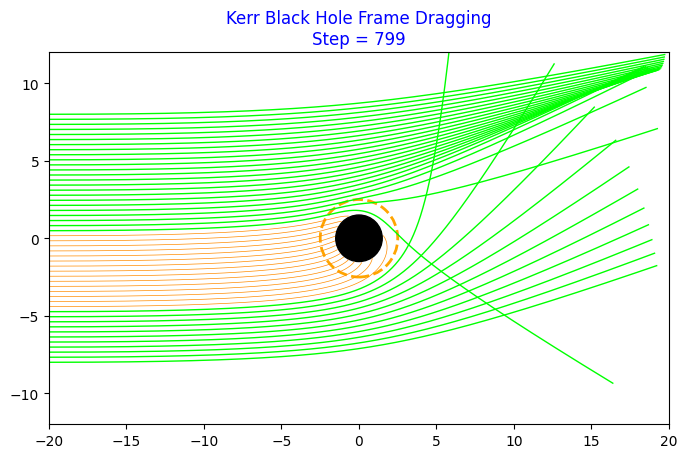

In [8]:
M = 1
a = 0.8      # spin parameter
dt = 0.05
steps = 800
rays = []
for y0 in np.linspace(-8,8,50):
    rays.append({"x": -20, "y": y0, "vx": 1.0, "vy": 0.0, "xs": [], "ys": [], "alive": True, "captured": False})

fig, ax = plt.subplots(figsize=(8,8))
for step in range(steps):
    clear_output(wait=True)
    ax.clear()
    ax.add_patch(plt.Circle((0,0),1.5,color='black'))
    ax.add_patch(plt.Circle((0,0), 2.5, color='orange', fill=False, linestyle='--', lw=2))
    for ray in rays:
        if ray["captured"]:
            ax.plot(ray["xs"], ray["ys"], color='darkorange', lw=0.5)
            continue

        if not ray["alive"]:
            continue

        x, y = ray["x"], ray["y"]
        vx, vy = ray["vx"], ray["vy"]
        r = np.sqrt(x**2 + y**2)
        if r < 1.6:
            ray["xs"].append(x)
            ray["ys"].append(y)
            ray["alive"] = False
            ray["captured"] = True
            continue

        factor = 1 + 8/(r**2)
        axx = -factor*M*x/(r**4)
        ayy = -factor*M*y/(r**4)
        axx += -a*vy/(r**2)
        ayy +=  a*vx/(r**2)
        vx += axx*dt
        vy += ayy*dt
        speed = np.sqrt(vx**2 + vy**2)
        vx /= speed
        vy /= speed
        x += vx*dt
        y += vy*dt
        ray["x"], ray["y"] = x, y
        ray["vx"], ray["vy"] = vx, vy
        ray["xs"].append(x)
        ray["ys"].append(y)
        ax.plot(ray["xs"], ray["ys"], color='lime', lw=1)
    ax.set_xlim(-20,20)
    ax.set_ylim(-12,12)
    ax.set_aspect('equal')
    ax.set_title(f"Kerr Black Hole Frame Dragging\nStep = {step}",color='blue')
    display(fig)
    time.sleep(0.001)
plt.close()

### Relativistic Zoom–Whirl Geodesics in Schwarzschild Spacetime

Effective potential:

$\qquad\displaystyle V_{\mathrm{eff}}(r)=\left(1-\frac{2M}{r}\right)\left(1+\frac{L^2}{r^2}\right)$

Relativistic energy equation:

$\qquad\displaystyle \left(\frac{dr}{d\tau}\right)^2+V_{\mathrm{eff}}(r)=E^2$

Radial motion:

$\qquad\displaystyle \frac{dr}{d\tau}=-\sqrt{E^2-V_{\mathrm{eff}}(r)}$

Angular motion:

$\qquad\displaystyle \frac{d\phi}{d\tau}=\frac{L}{r^2}$

Cartesian coordinates:

$\qquad\displaystyle x=r\cos\phi\qquad\,y=r\sin\phi$

Schwarzschild metric:

$\qquad\displaystyle ds^2=-\left(1-\frac{2M}{r}\right)dt^2+\left(1-\frac{2M}{r}\right)^{-1}dr^2+r^2(d\theta^2+\sin^2\theta\,d\phi^2)$

Photon sphere radius:

$\qquad\displaystyle r_{\mathrm{ph}}=3M$


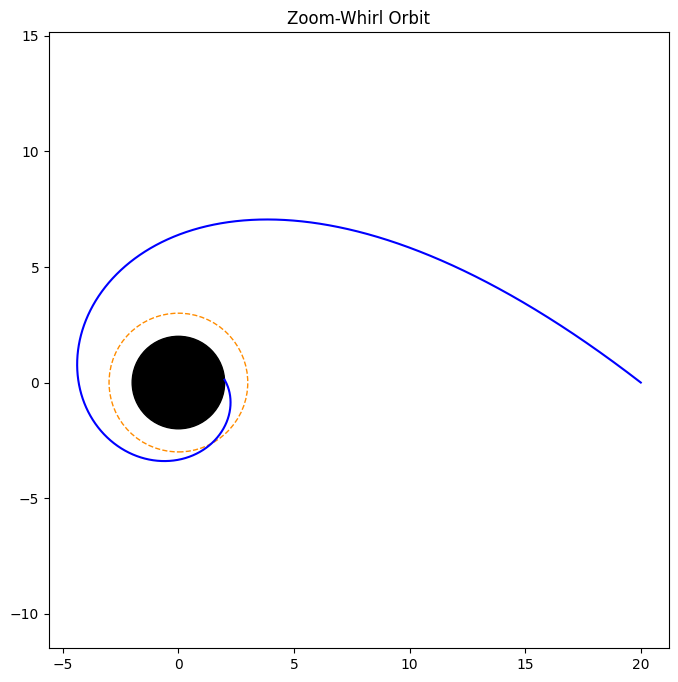

In [9]:
M = 1
L = 3.9
E = 0.999
dt = 0.002
steps = 400000
r = 20
phi = 0
xs = []
ys = []
for n in range(steps):
    Veff = (1-2*M/r)*(1+L**2/r**2)
    dr = -np.sqrt(abs(E**2 - Veff))
    dphi = L/r**2
    r += dr*dt
    phi += dphi*dt
    x = r*np.cos(phi)
    y = r*np.sin(phi)
    xs.append(x)
    ys.append(y)
    if r < 2:
        break

plt.figure(figsize=(8,8))
plt.plot(xs,ys,color='blue')
plt.gca().add_patch(plt.Circle((0,0),2,color='black'))
plt.gca().add_patch(plt.Circle((0,0),3,fill=False,linestyle='--',color='darkorange'))
plt.axis('equal')
plt.title("Zoom-Whirl Orbit")
plt.show()

### Chaotic Perturbation of a Near-Circular Photon Orbit

Photon sphere radius:

$\qquad\displaystyle r_{\mathrm{ph}}=3M$

Angular motion:

$\qquad\displaystyle \frac{d\phi}{d\tau}=\frac{1}{r^2}$

Perturbed radial velocity:

$\qquad\displaystyle v_r\rightarrow v_r+\epsilon\,\eta(t)$

where

$\qquad\displaystyle \eta(t)\sim\mathcal{N}(0,1)$

Radial evolution:

$\qquad\displaystyle r\rightarrow r+v_r\,dt$

Cartesian coordinates:

$\qquad\displaystyle x=r\cos\phi\qquad\,y=r\sin\phi$

Schwarzschild metric:

$\qquad\displaystyle ds^2=-\left(1-\frac{2M}{r}\right)dt^2+\left(1-\frac{2M}{r}\right)^{-1}dr^2+r^2(d\theta^2+\sin^2\theta\,d\phi^2)$

Null geodesic equation:

$\qquad\displaystyle \frac{d^2u}{d\phi^2}+u=3Mu^2$

with

$\qquad\displaystyle u=\frac{1}{r}$

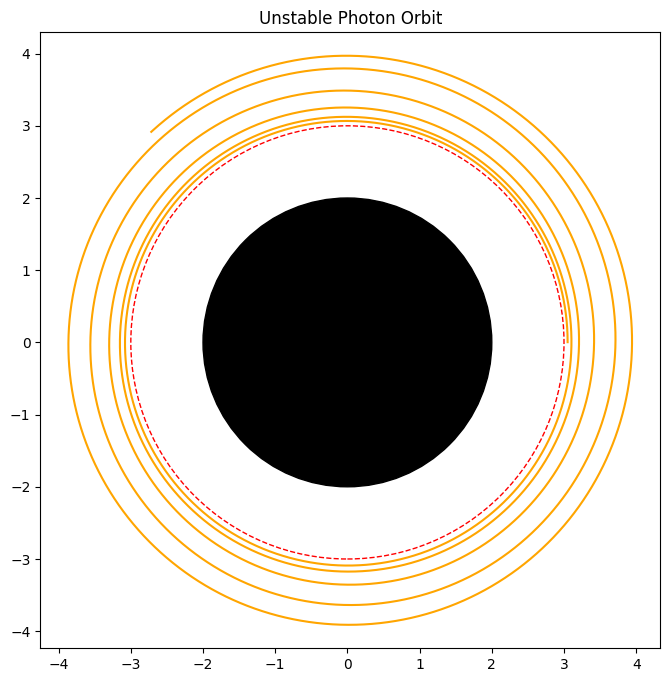

In [10]:
M = 1
r = 3.05
phi = 0
vr = 0.001
dt = 0.01
xs = []
ys = []
for n in range(40000):
    dphi = 1/r**2
    vr += 0.00001*np.random.randn()
    r += vr*dt
    phi += dphi*dt
    x = r*np.cos(phi)
    y = r*np.sin(phi)
    xs.append(x)
    ys.append(y)
    if r < 2 or r > 20:
        break

plt.figure(figsize=(8,8))
plt.plot(xs,ys,color='orange')
plt.gca().add_patch(plt.Circle((0,0),2,color='black'))
plt.gca().add_patch(plt.Circle((0,0),3,fill=False,linestyle='--',color='red'))
plt.axis('equal')
plt.title("Unstable Photon Orbit")
plt.show()

### Gravitational Lensing Around a Schwarzschild Black Hole

Schwarzschild metric:

$\qquad\displaystyle ds^2=-\left(1-\frac{R_s}{r}\right)c^2dt^2+\left(1-\frac{R_s}{r}\right)^{-1}dr^2+r^2(d\theta^2+\sin^2\theta\,d\phi^2)$

with

$\qquad\displaystyle R_s=\frac{2GM}{c^2}$

Photon geodesic equation:

$\qquad\displaystyle \frac{d^2u}{d\phi^2}=\frac{3}{2}R_su^2-u$

with

$\qquad\displaystyle u=\frac{1}{r}$

Initial conditions:

$\qquad\displaystyle u(0)=\frac{1}{D}$

$\qquad\displaystyle\frac{du}{d\phi}(0)=\frac{1}{D\tan\alpha}$

Deflection angle relation:

$\qquad\displaystyle\theta_{\mathrm{dev}}=\phi_f+\arcsin\left(\frac{D}{r_f}\sin\phi_f\right)$

Interpolation mapping:

$\qquad\displaystyle\theta_{\mathrm{seen}}\rightarrow\theta_{\mathrm{dev}}$

Spherical to Cartesian transformation:

$\qquad\displaystyle x=\sin\theta\cos\phi$

$\qquad\displaystyle y=\sin\theta\sin\phi$

$\qquad\displaystyle z=\cos\theta$

Cartesian to spherical transformation:

$\qquad\displaystyle\theta=\cos^{-1}(z)$

$\qquad\displaystyle\phi=\tan^{-1}\left(\frac{y}{x}\right)$

Rotation matrix:

$\qquad\displaystyle R_x(\beta)=\begin{pmatrix}1&0&0\\ 0&\cos\beta&-\sin\beta\\ 0&\sin\beta&\cos\beta \end{pmatrix}$

Angular remapping:

$\qquad\displaystyle \phi\rightarrow\phi'$

Pixel coordinate mapping:

$\qquad\displaystyle x_{\mathrm{pix}}=\phi\frac{360}{FOV}\,R_x$

$\qquad\displaystyle y_{\mathrm{pix}}=\theta\frac{180}{FOV_Y}\,R_y$

Image transformation pipeline:

$\qquad\displaystyle (x,y)\rightarrow(\theta,\phi)\rightarrow(\theta,\phi')\rightarrow(x',y')$
 
Weak-field gravitational lensing approximation:

$\qquad\displaystyle\alpha\approx\frac{4GM}{c^2b}$

Photon sphere radius:

$\qquad\displaystyle r_{\mathrm{ph}}=\frac{3}{2}R_s$

Event horizon radius:

$\qquad\displaystyle r=R_s$

Numerical ray-tracing mapping:

$\qquad\displaystyle I(x,y)\rightarrow I(x',y')$


<Figure size 640x480 with 0 Axes>

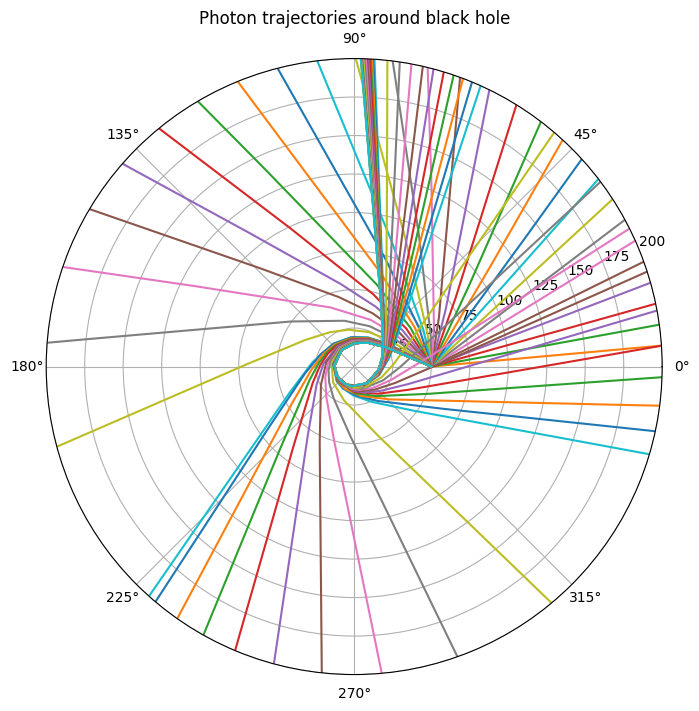

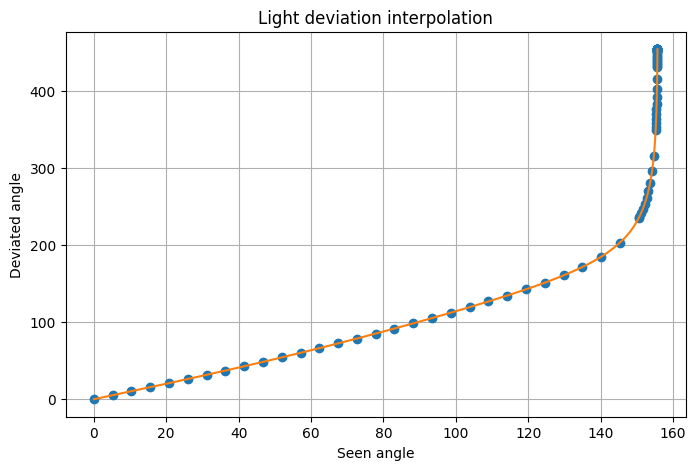

In [2]:
M_sun = 1.98840987e30
Rs = 8
D = 50
axe_X = 600
FOV_img = 360
kind = 'cubic'
display_trajectories = True
display_interpolation = True

def create_default_image(size=1000, pattern="grid"):
    axe_X = size
    axe_Y = size // 2
    img = Image.new('RGB', (axe_X, axe_Y), color=255)
    drawer = ImageDraw.Draw(img)
    drawer.rectangle((0, 0, axe_X/2, axe_Y/2), fill="yellow")
    drawer.rectangle((0, axe_Y/2, axe_X/2, axe_Y), fill="green")
    drawer.rectangle((axe_X/2, 0, axe_X, axe_Y/2), fill="blue")
    drawer.rectangle((axe_X/2, axe_Y/2, axe_X, axe_Y), fill="red")
    nbr_rect = 40
    if pattern == "grid":

        for i in range(0, axe_X, axe_X//nbr_rect):
            drawer.line((i, 0, i, axe_Y), fill="black", width=2)

        for i in range(0, axe_Y, axe_Y//(nbr_rect//2)):
            drawer.line((0, i, axe_X, i), fill="black", width=2)

    return img

def img_resize(img_original, axe_X):
    img = img_original.convert("RGB")
    size_X, size_Y = img.size
    scale = axe_X / size_X
    axe_Y = int(scale * size_Y)

    if axe_X % 2 != 0:
        axe_X -= 1

    if axe_Y % 2 != 0:
        axe_Y -= 1

    img = img.resize((axe_X, axe_Y), Image.Resampling.LANCZOS)
    return img, axe_X, axe_Y

def diff_eq(phi, u):
    u0 = u[0]
    u1 = u[1]
    du0 = u1
    du1 = 1.5 * Rs * u0**2 - u0
    return [du0, du1]


def eventRs(phi, u):
    return 1/u[0] - Rs

eventRs.terminal = True
 
def solver(alpha):
    if alpha == 0:
        return [0], [0]

    if alpha == 180:
        return [D], [0]

    y0 = [ 1/D, 1/(D * np.tan(np.radians(alpha)))]
    sol = sc.integrate.solve_ivp(diff_eq, [0, 10*np.pi], y0, method='Radau', events=[eventRs])
    phi = np.array(sol.t)
    r = np.abs(1 / sol.y[0])
    return r, phi

def search_alpha_min():
    alpha_min = 0
    for alpha in range(0, 180, 4):
        r = solver(alpha)[0]
        if r[-1] > 1.1 * Rs:
            break

    if (alpha - 4) > 0:
        alpha_min = alpha - 4

    i = 1
    while alpha_min == 0 or round(alpha_min) != round(alpha_min + i*10):
        for alpha in range(int(alpha_min/i), int(180/i), 1):
            alpha = alpha * i
            r = solver(alpha)[0]
            if r[-1] > 1.1 * Rs:
                break

        if (alpha - i) > 0:
            alpha_min = alpha - i

        i = i / 10
    i = 10 * i
    alpha_min += i
    return alpha_min

def trajectories():
    alpha_min = search_alpha_min()
    alpha_finder = FOV_img / 2
    seen_angle = np.array([])
    deviated_angle = np.array([])
    clear_output(wait=True)
    plt.clf()
    fig = plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, projection='polar')
    ax.set_title("Photon trajectories around black hole")
    ax.set_rlim((0, 4*D))
    booli = False
    points = 30
    for i in range(6):
        for alpha in np.linspace(alpha_finder, alpha_min, num=points, endpoint=booli):
            r, phi = solver(alpha)
            if r[-1] > 1.1 * Rs:
                seen_angle = np.append(seen_angle, 180 - alpha)
                dev_angle = (phi[-1] + np.arcsin(D/r[-1] * np.sin(phi[-1])))
                dev_angle = np.degrees(dev_angle)
                deviated_angle = np.append(deviated_angle, dev_angle)
                ax.plot(phi, r)
                clear_output(wait=True)
                display(fig)
        alpha_finder = alpha_min + (alpha_finder - alpha_min) / (points + 1)
        points = 10
        if i == 4:
            booli = True
    return seen_angle, deviated_angle
 
def interpolation_plot(seen_angle, deviated_angle):
    interpolation = sc.interpolate.interp1d(seen_angle,deviated_angle,kind=kind,bounds_error=False)
    xmin = np.min(seen_angle)
    xmax = np.max(seen_angle)
    xfine = np.linspace(xmin, xmax, 2000)
    yfine = interpolation(xfine)
    clear_output(wait=True)
    plt.figure(figsize=(8, 5))
    plt.title("Light deviation interpolation")
    plt.xlabel("Seen angle")
    plt.ylabel("Deviated angle")
    plt.plot(seen_angle, deviated_angle, 'o')
    plt.plot(xfine, yfine)
    plt.grid()
    plt.show()
    return interpolation

print("Creating image...") 
img_original = create_default_image(size=1200, pattern="grid")
img, axe_X, axe_Y = img_resize(img_original,axe_X) 
print("Computing trajectories...") 
seen_angle, deviated_angle = trajectories() 
print("Interpolation...") 
interpolation = interpolation_plot(seen_angle, deviated_angle)

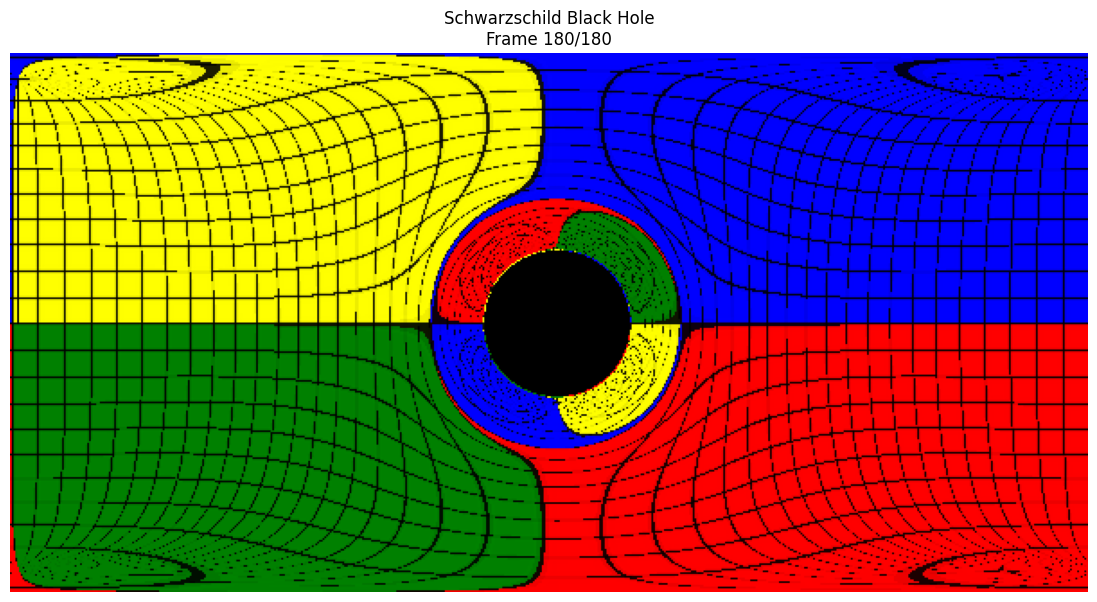

In [3]:
def spheric2cart(theta, phi):
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    return x, y, z

def cart2spheric(x, y, z):
    theta = np.arccos(z)
    phi = np.arctan2(y, x)
    return theta, phi

def rotation_matrix(beta):
    beta = np.array(beta)
    c = np.cos(beta)
    s = np.sin(beta)
    zero = np.zeros(beta.shape)
    one = np.ones(beta.shape)
    return np.array([[ one, zero, zero],
                     [zero,    c,   -s],
                     [zero,    s,    c]])

def img_offset_X(img, offset_X):
    arr = np.array(img)
    arr2 = np.roll(arr, int(offset_X), axis=1)
    return Image.fromarray(arr2.astype('uint8'))

def create_matrices(interpolation,axe_X,axe_Y,cx_shift=0):
    img_res = axe_X / 360
    img_res_Y = axe_Y / 180
    FOV_img_Y = FOV_img * axe_Y / axe_X
    x = np.arange(0, axe_X)
    y = np.arange(0, axe_Y)
    xv, yv = np.meshgrid(x, y)
    xv_shifted = xv - cx_shift
    xv_shifted = np.mod(xv_shifted, axe_X)
    phi = xv_shifted * FOV_img / 360 / img_res
    theta = yv * FOV_img_Y / 180 / img_res_Y
    phi2 = phi + (360 - FOV_img)/2
    theta2 = theta + (180 - FOV_img_Y)/2
    u, v, w = spheric2cart(np.radians(theta2),np.radians(phi2))
    beta = -np.arctan(w/v)
    matrix = rotation_matrix(beta)
    u2 = matrix[0,0]*u
    v2 = matrix[1,1]*v + matrix[1,2]*w
    w2 = matrix[2,1]*v + matrix[2,2]*w
    _, seen_angle = cart2spheric(u2, v2, w2)
    seen_angle = np.degrees(seen_angle)
    seen_angle = np.mod(seen_angle, 360)
    deviated_angle = np.zeros(seen_angle.shape)
    mask = seen_angle < 180
    deviated_angle[mask] = interpolation(seen_angle[mask])
    deviated_angle[~mask] = (360 - interpolation(360 - seen_angle[~mask]))
    theta = np.pi/2
    phi = np.radians(deviated_angle)
    u3, v3, w3 = spheric2cart(theta, phi)
    matrix = rotation_matrix(-beta)
    u4 = matrix[0,0]*u3
    v4 = matrix[1,1]*v3 + matrix[1,2]*w3
    w4 = matrix[2,1]*v3 + matrix[2,2]*w3
    theta, phi = cart2spheric(u4, v4, w4)
    theta = np.degrees(theta)
    phi = np.degrees(phi)
    phi -= (360 - FOV_img)/2
    theta -= (180 - FOV_img_Y)/2
    phi = np.mod(phi, 360)
    theta = np.mod(theta, 180)
    xv2 = phi * 360/FOV_img * img_res
    yv2 = theta * 180/FOV_img_Y * img_res_Y
    xv2[np.isnan(xv2)] = -1
    yv2[np.isnan(yv2)] = -1
    return xv2.astype(int), yv2.astype(int)
    

def img_pixels(img, img_matrix_x, img_matrix_y):
    pixels = np.array(img)
    h, w = pixels.shape[:2]
    xv = img_matrix_x.copy()
    yv = img_matrix_y.copy()
    valid = ((xv >= 0) & (xv < w) & (yv >= 0) & (yv < h))
    xv = np.mod(xv, w)
    yv = np.mod(yv, h)
    output = np.zeros_like(pixels)
    output[:, :] = pixels[yv, xv]
    output[~valid] = [0, 0, 0]
    return Image.fromarray(output.astype('uint8'))
 
def black_hole(img, interpolation, axe_X, axe_Y, frames=160, pause=0.015):
    width = img.size[0]
    fig, ax = plt.subplots(figsize=(14,7))
    display(fig)
    for i in range(frames):
        bg_shift = int(i * width / frames)
        moved_img = img_offset_X(img, bg_shift)
        bh_shift = -int(i * axe_X / frames)
        img_matrix_x, img_matrix_y = create_matrices(interpolation, axe_X, axe_Y, cx_shift=bh_shift)
        lensed = img_pixels(moved_img, img_matrix_x, img_matrix_y)
        clear_output(wait=True)
        ax.clear()
        ax.imshow(lensed)
        ax.set_title(f"Schwarzschild Black Hole\nFrame {i+1}/{frames}")
        ax.axis("off")
        display(fig)
        time.sleep(pause)
    plt.close(fig)

print("Creating matrices...")
print("Applying black hole lensing...")
black_hole(img, interpolation, axe_X, axe_Y, frames=180, pause=0.015)

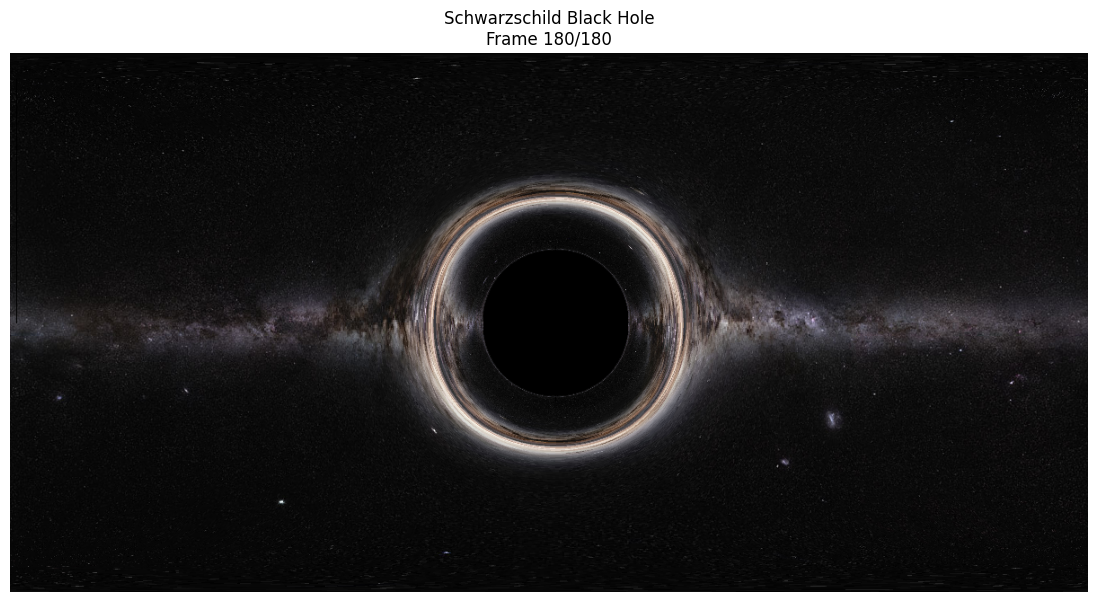

In [5]:
img = Image.open("milkyway.jpg").convert("RGB")
axe_X = 1200
axe_Y = 600
img = img.resize((axe_X, axe_Y))
print("Creating matrices...")
print("Applying black hole lensing...")
black_hole(img, interpolation, axe_X, axe_Y, frames=180, pause=0.015)

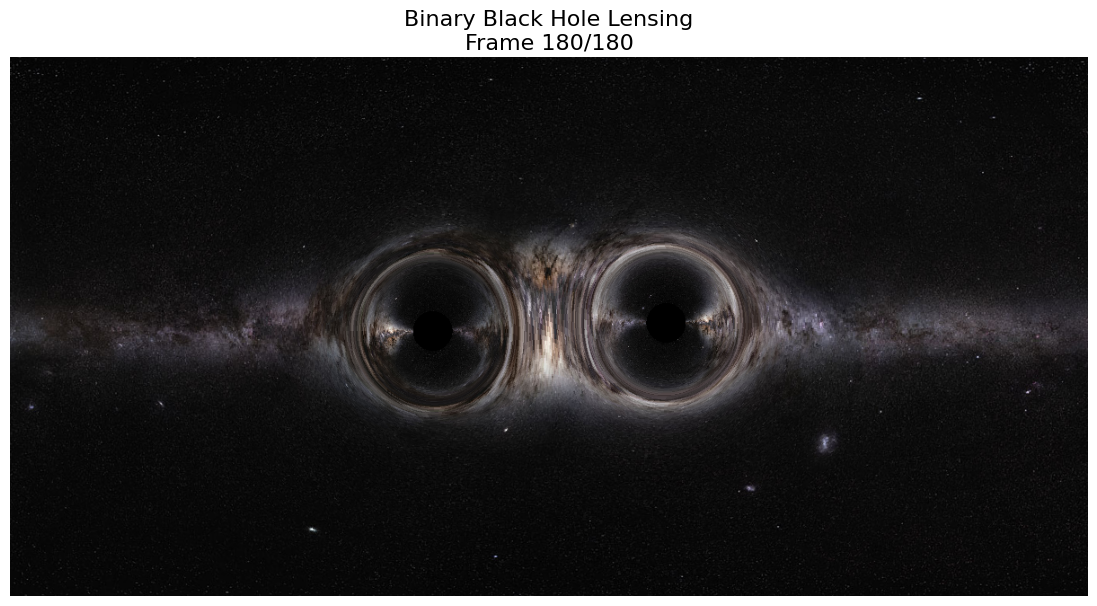

In [7]:
SIZE_X = 1000
SIZE_Y = 500
FRAMES = 240
BH_RADIUS = 22          # shadow size
LENS_STRENGTH = 7000    # lensing strength
ORBIT_RADIUS = 130      # binary separation

def img_offset_X(img, offset_X):
    arr = np.array(img)
    arr2 = np.roll(arr, int(offset_X), axis=1)
    return Image.fromarray(arr2.astype(np.uint8))
    
def create_sky(size_x=1000,size_y=500):
    img = Image.new("RGB",(size_x,size_y),"black")
    draw = ImageDraw.Draw(img)
    rng = np.random.default_rng(42)
    for _ in range(5000):
        x = rng.integers(0,size_x)
        y = rng.integers(0,size_y)
        b = rng.integers(150,255)
        draw.point((x,y),fill=(b,b,b))
    return img

def sample_image(img,xmap,ymap):
    arr = np.array(img)
    h,w = arr.shape[:2]
    xmap = np.clip(xmap.astype(int),0,w-1)
    ymap = np.clip(ymap.astype(int),0,h-1)
    return arr[ymap,xmap]                      

def binary_lens(img,cx1,cy1,cx2,cy2):
    arr = np.array(img)
    h,w = arr.shape[:2]
    Y,X = np.indices((h,w))
    eps = 10
    dx1 = X-cx1
    dy1 = Y-cy1
    r1sq = dx1**2 + dy1**2 + eps
    ax1 = LENS_STRENGTH*dx1/r1sq
    ay1 = LENS_STRENGTH*dy1/r1sq

    dx2 = X-cx2
    dy2 = Y-cy2
    r2sq = dx2**2 + dy2**2 + eps
    ax2 = LENS_STRENGTH*dx2/r2sq
    ay2 = LENS_STRENGTH*dy2/r2sq

    alpha_x = ax1 + ax2
    alpha_y = ay1 + ay2
    source_x = X - alpha_x
    source_y = Y - alpha_y
    lensed = sample_image(img,source_x,source_y)
    r1 = np.sqrt(dx1**2+dy1**2)
    r2 = np.sqrt(dx2**2+dy2**2)
    shadow = (r1 < BH_RADIUS) | (r2 < BH_RADIUS)
    lensed[shadow] = [0,0,0]
    return Image.fromarray(lensed)

def animate_binary(img, frames=180, pause=0.015):
    fig, ax = plt.subplots(figsize=(14,7))
    display(fig)
    width = img.size[0]
    for frame in range(frames):
        bg_shift = int(frame * width / frames)
        moved_img = img_offset_X(img, bg_shift)
        angle = 2*np.pi*frame/frames
        cx1 = axe_X/2 + ORBIT_RADIUS*np.cos(angle)
        cy1 = axe_Y/2 + ORBIT_RADIUS*np.sin(angle)
        cx2 = axe_X/2 - ORBIT_RADIUS*np.cos(angle)
        cy2 = axe_Y/2 - ORBIT_RADIUS*np.sin(angle)
        lensed = binary_lens(moved_img,cx1,cy1,cx2,cy2)
        clear_output(wait=True)
        ax.clear()
        ax.imshow(lensed)
        ax.set_title( f"Binary Black Hole Lensing\nFrame {frame+1}/{frames}",fontsize=16)
        ax.axis("off")
        display(fig)
        time.sleep(pause)
    plt.close(fig)

img = Image.open("milkyway.jpg").convert("RGB")
axe_X = 1200
axe_Y = 600
img = img.resize((axe_X, axe_Y))
print("Applying binary black hole lensing...")
animate_binary(img,frames=180,pause=0.015)